<h1 align="center"> TP : Principal Component Analysis </h1>

<pre align="left"> January 21th 2026               <i> </i>               <i> Answers: Mohamed Yassine Khales </i></pre>
* * *

In [259]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1


In [260]:
def rmvt(mu, Sigma, free_deg, num_points):
    Z = np.random.multivariate_normal(np.zeros_like(mu), Sigma, size=num_points)
    W = np.random.chisquare(free_deg, (num_points,1))
    X = mu+np.sqrt(free_deg/W)*Z
    return X

<Figure size 640x480 with 0 Axes>

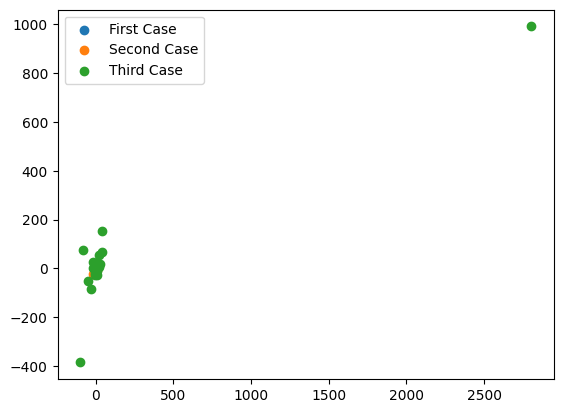

<Figure size 640x480 with 0 Axes>

In [261]:
# Test

mu = [0,0]; Sigma = [[1,1], [1,4]]; free_deg = 5; num_points = 100
X = rmvt(mu, Sigma, free_deg, num_points)
plt.scatter(X[:,0], X[:,1], label = "First Case")

mu = [2,2]; Sigma = [[1,1], [1,4]]; free_deg = 3; num_points = 100
X = rmvt(mu, Sigma, free_deg, num_points)
plt.scatter(X[:,0], X[:,1], label = "Second Case")

mu = [2,2]; Sigma = [[4,4], [4,16]]; free_deg = 1; num_points = 100
X = rmvt(mu, Sigma, free_deg, num_points)
plt.scatter(X[:,0], X[:,1], label="Third Case")

plt.legend()
plt.figure()




## Question 2

In [262]:
cov_X = [[1,1,1],[1,4,4], [1,4,9]]
X = rmvt([0,0,0], cov_X, 5, 1000)

# Projection and normalization
proj_matrix = np.array([[1,1,1,1,1],[1,-1,1,-1,0],[0,-1,-1,0,2]]).T
print(X.shape)
print(proj_matrix.shape)
proj_matrix = proj_matrix/np.linalg.norm(proj_matrix, axis=0)
final_X = X @ proj_matrix.T

# Shifting
shifting = np.array([[1,2,3,4,5]]*len(final_X))
final_X = final_X+shifting

# Noising
mu_noise = [0,0,0,0,0]
sigma_noise = np.diag([0.025, 0.025,0.025,0.025,0.025])
noise = np.random.multivariate_normal(mu_noise, sigma_noise, len(final_X))
X = final_X + noise

(1000, 3)
(5, 3)


## Question 3

In [263]:
from sklearn.decomposition import PCA

In [264]:
pca = PCA()
pca.fit(X)
comp=pca.components_

In [265]:
print(comp)

[[ 0.2964829  -0.53515397 -0.05704959 -0.18051675  0.76802811]
 [ 0.53439465 -0.09030861  0.7384371  -0.2858425  -0.28155182]
 [ 0.26675568  0.57003953  0.27003133  0.57380118  0.44914544]
 [ 0.48492978 -0.41713812 -0.30176664  0.61028533 -0.35682996]
 [ 0.56586639  0.45442855 -0.53616786 -0.42896596 -0.04245178]]


In [266]:
X_pca = pca.transform(X)

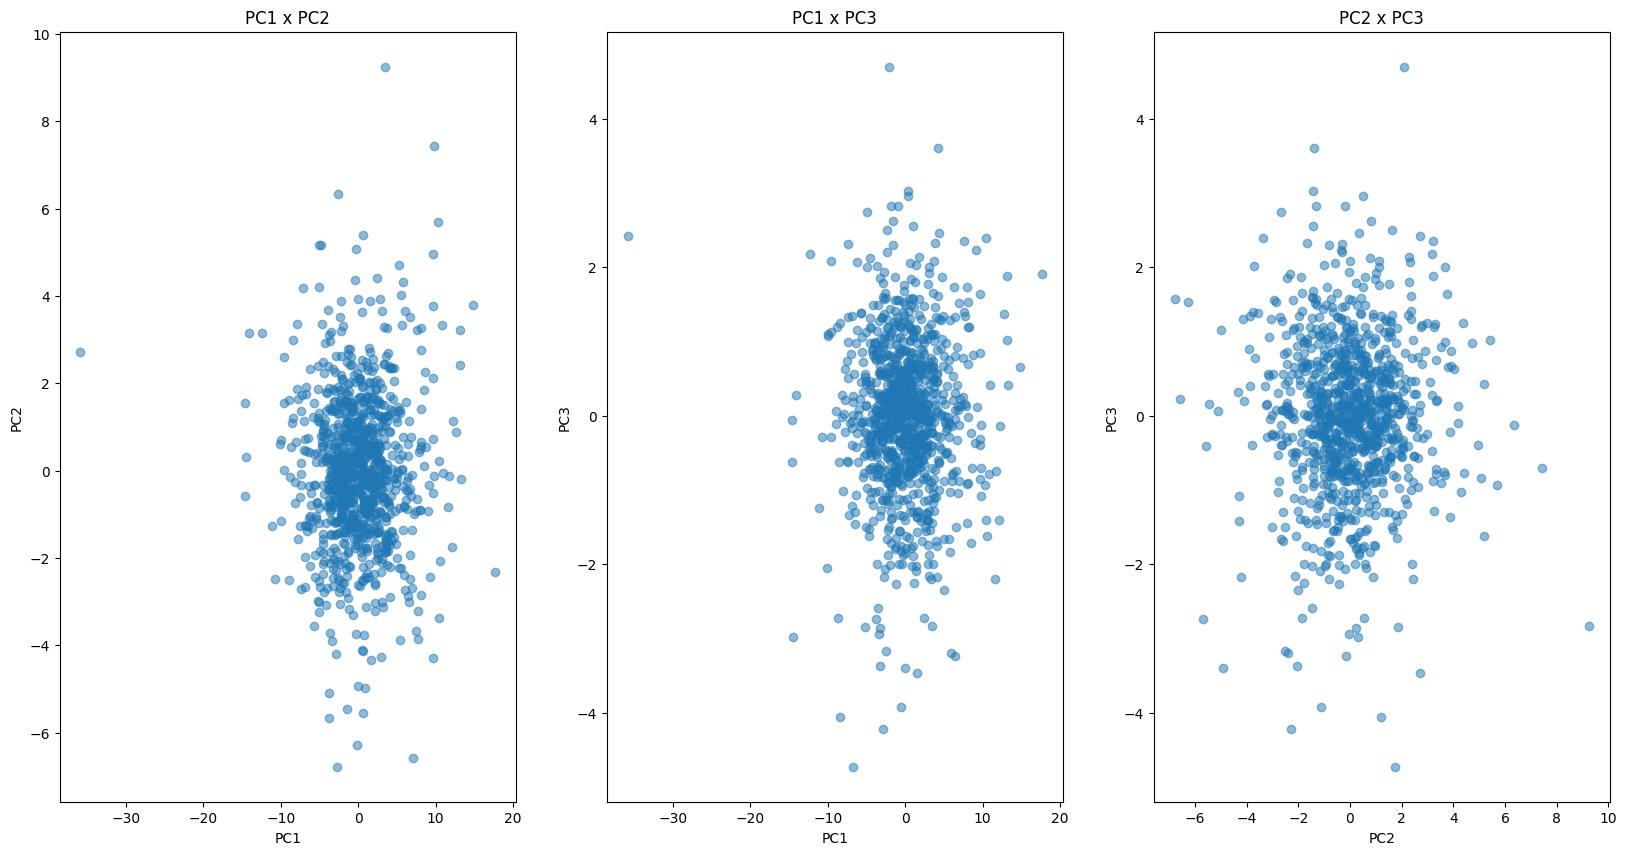

In [267]:
fig, axs = plt.subplots(1,3, figsize=(20,10))
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title('PC1 x PC2')

axs[1].scatter(X_pca[:, 0], X_pca[:, 2], alpha=0.5)
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC3')
axs[1].set_title('PC1 x PC3')

axs[2].scatter(X_pca[:, 1], X_pca[:, 2], alpha=0.5)
axs[2].set_xlabel('PC2')
axs[2].set_ylabel('PC3')
axs[2].set_title('PC2 x PC3')
plt.show()

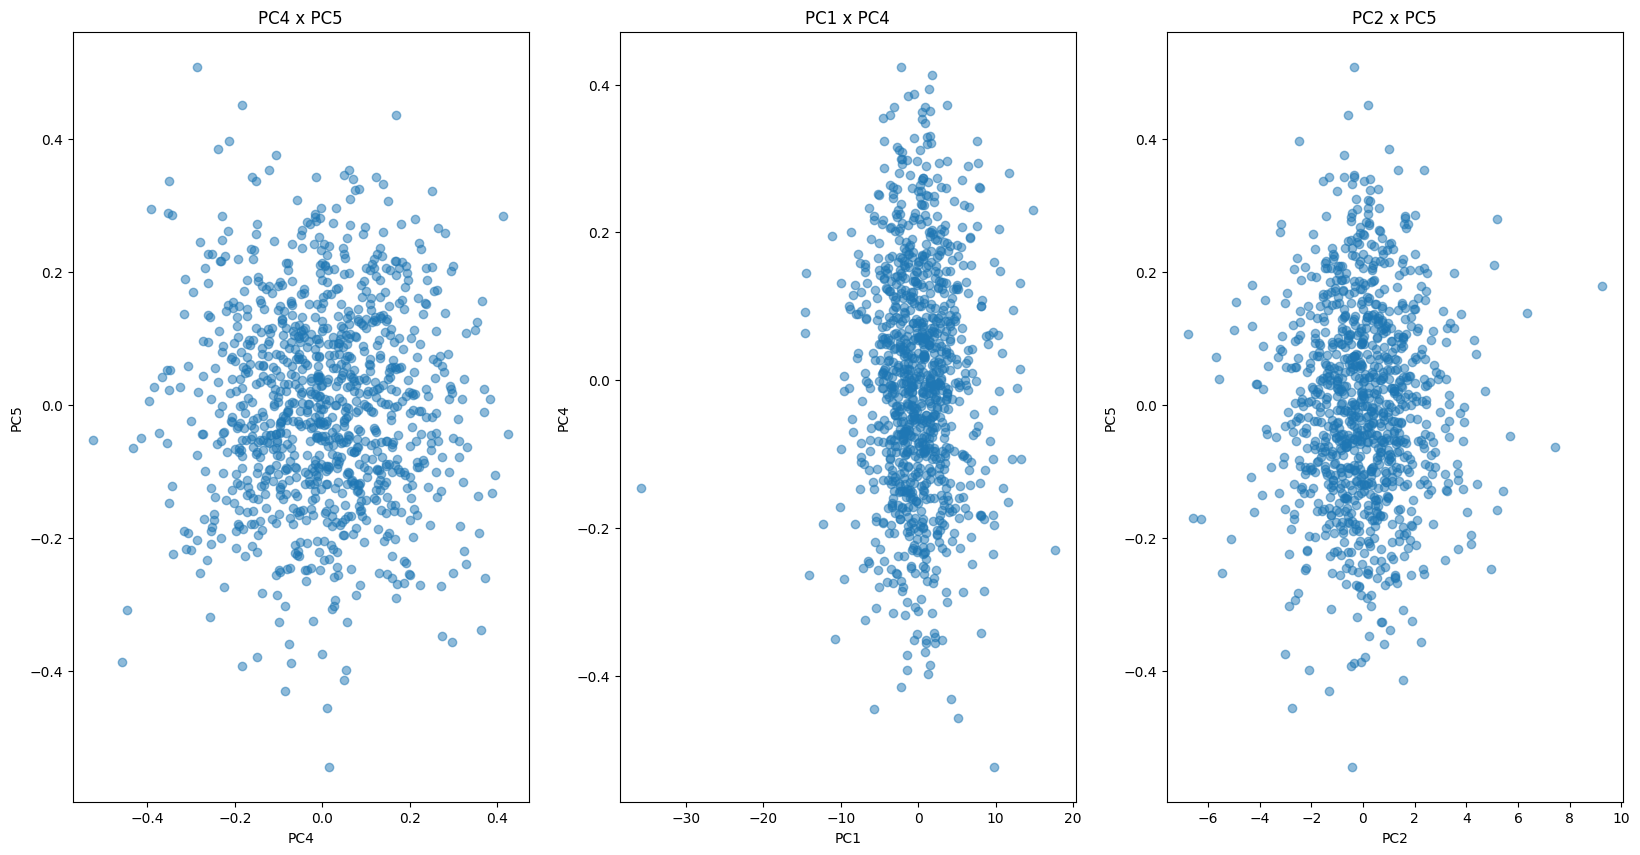

In [268]:
fig, axs = plt.subplots(1,3, figsize=(20,10))
axs[0].scatter(X_pca[:, 3], X_pca[:, 4], alpha=0.5)
axs[0].set_xlabel('PC4')
axs[0].set_ylabel('PC5')
axs[0].set_title('PC4 x PC5')

axs[1].scatter(X_pca[:, 0], X_pca[:, 3], alpha=0.5)
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC4')
axs[1].set_title('PC1 x PC4')

axs[2].scatter(X_pca[:, 1], X_pca[:, 4], alpha=0.5)
axs[2].set_xlabel('PC2')
axs[2].set_ylabel('PC5')
axs[2].set_title('PC2 x PC5')
plt.show()

**Comments :**

We see that PC1 goes from $-25$ to $25$.
For the first three plot : 
- For PC1 x PC2 and PC1 x PC3, they are wide in the vertical way.
- For PC2 x PC3 it is almost symetric to the origin (0,0)

For the last three plot :
- For PC4 x PC5 : they are close to the origin.
- For PC1 x PC4 it is wide in the vertical way but not as much as the first ones, since it goes vertically from $-0.4$ to $0.4$.
- For PC2 x PC5 :It is also very condensed near the origin.

## Question 4
The SVD decomposition

In [269]:
A = np.cov(X.T)
U, S, Vh = np.linalg.svd(A)
D = np.zeros((U.shape[0], Vh.shape[0]))
D[:len(S),:len(S)] = np.diag(S)
A2 = U @ D @ Vh

print(f"The difference between SVD and A = cov(X.T) : {np.linalg.norm(A-A2)}")
print(f"The difference between SVD and PCA : {np.linalg.norm(np.abs(comp)-np.abs(Vh))}")

The difference between SVD and A = cov(X.T) : 6.426359854807726e-15
The difference between SVD and PCA : 5.414829982499585e-12


In [270]:
print(f"PCA components :\n{comp}")
print(f"SVD components :\n{Vh}")

PCA components :
[[ 0.2964829  -0.53515397 -0.05704959 -0.18051675  0.76802811]
 [ 0.53439465 -0.09030861  0.7384371  -0.2858425  -0.28155182]
 [ 0.26675568  0.57003953  0.27003133  0.57380118  0.44914544]
 [ 0.48492978 -0.41713812 -0.30176664  0.61028533 -0.35682996]
 [ 0.56586639  0.45442855 -0.53616786 -0.42896596 -0.04245178]]
SVD components :
[[-0.2964829   0.53515397  0.05704959  0.18051675 -0.76802811]
 [-0.53439465  0.09030861 -0.7384371   0.2858425   0.28155182]
 [ 0.26675568  0.57003953  0.27003133  0.57380118  0.44914544]
 [ 0.48492978 -0.41713812 -0.30176664  0.61028533 -0.35682996]
 [ 0.56586639  0.45442855 -0.53616786 -0.42896596 -0.04245178]]


We see that the elements of SVD and PCA components are very close to each other. $$||c_{\text{PCA}}-c_{\text{SVD}}||^2 = 2.93 \times 10^{-12} \ll 1$$
So we can say that the two principal components coincide.

## Question 5

In [271]:
X_or=X.copy()

In [272]:
X[-100:]=rmvt([0,0,0,0,0], np.eye(5), 1, 100)

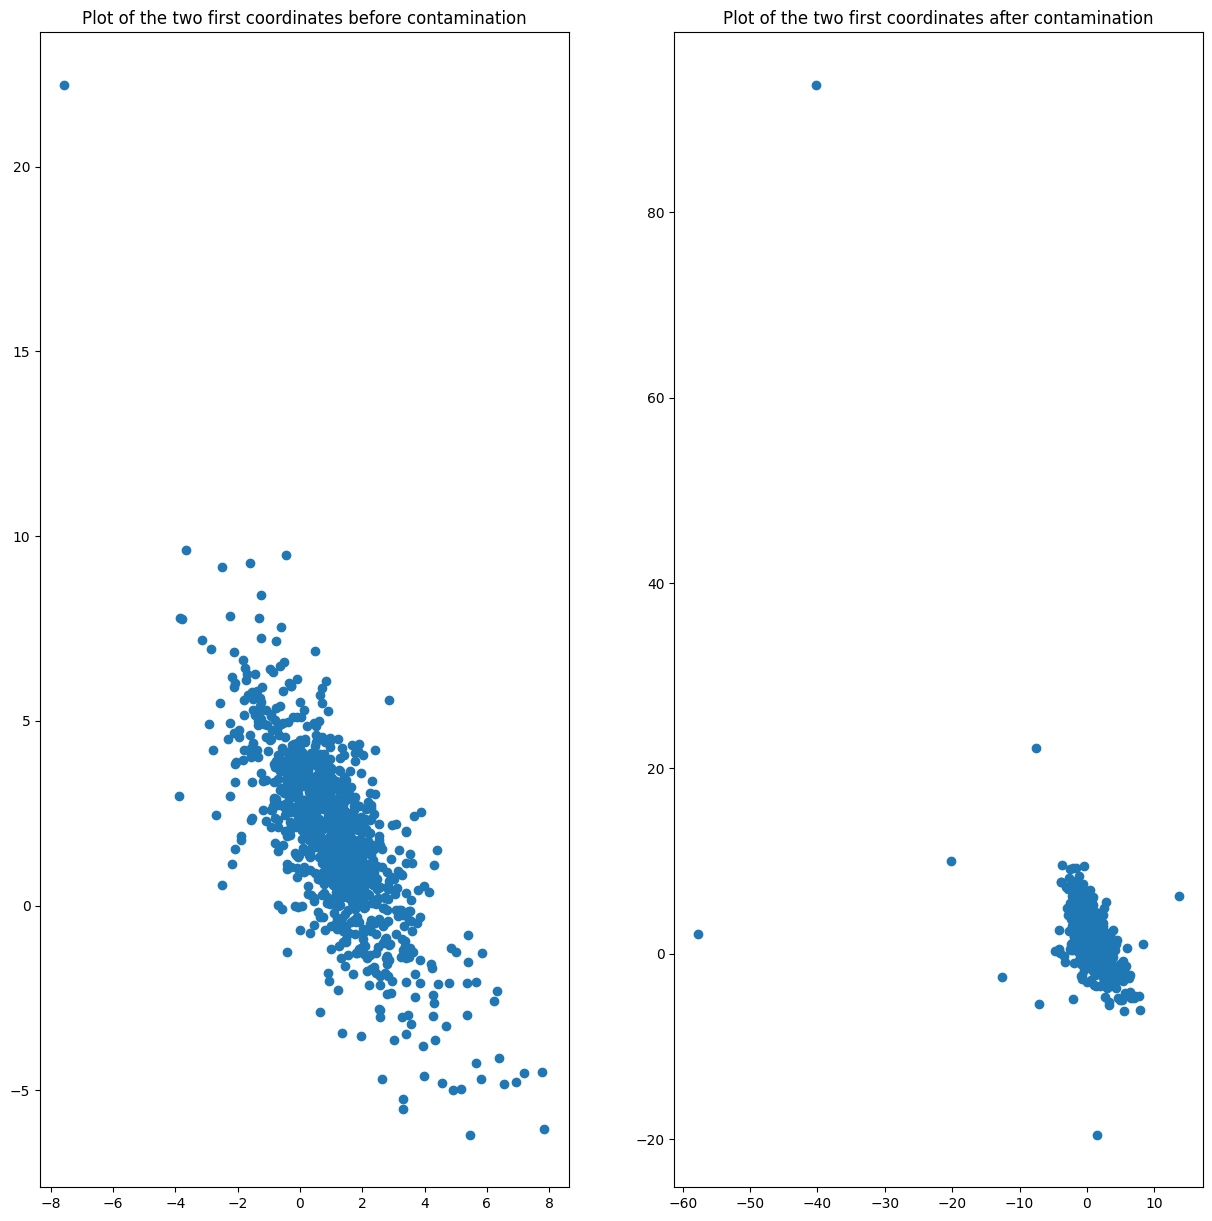

In [273]:
fig, axs = plt.subplots(1,2, figsize=(15,15))
axs[0].scatter(X_or[:,0], X_or[:,1])
axs[0].set_title("Plot of the two first coordinates before contamination")

axs[1].scatter(X[:,0], X[:,1])
axs[1].set_title("Plot of the two first coordinates after contamination")
plt.show()

**Conclusion :**

We find that there are some extreme values that appear after contamination.

## Question 6

### PCA on contaminated data

In [281]:
pca2 = PCA()
pca2.fit(X)
comp2=pca2.components_

exp_var = pca2.explained_variance_
sing_val = pca2.singular_values_
print(f"Explained variances : {exp_var}\n")
print(f"Singular values : {sing_val}")

Explained variances : [24.15468711 11.27639303  7.48981927  4.92581302  1.56786249]

Singular values : [155.34005414 106.13725377  86.50045923  70.14903567  39.57644027]


In [282]:
print(f"The difference between the two components : {np.linalg.norm(np.abs(comp2)-np.abs(comp))}")
print(f"PCA components before contamination :\n{comp}\n")
print(f"PCA components after contamination :\n{comp2}")

The difference between the two components : 1.0330885886407088
PCA components before contamination :
[[ 0.2964829  -0.53515397 -0.05704959 -0.18051675  0.76802811]
 [ 0.53439465 -0.09030861  0.7384371  -0.2858425  -0.28155182]
 [ 0.26675568  0.57003953  0.27003133  0.57380118  0.44914544]
 [ 0.48492978 -0.41713812 -0.30176664  0.61028533 -0.35682996]
 [ 0.56586639  0.45442855 -0.53616786 -0.42896596 -0.04245178]]

PCA components after contamination :
[[-0.43875825  0.69512229  0.1376476   0.0047665  -0.55256369]
 [ 0.21812842  0.46497041  0.61726469 -0.19314909  0.56382643]
 [-0.50765125  0.0525037  -0.05540042  0.72346615  0.46158541]
 [ 0.48551851 -0.09686828  0.453915    0.63057975 -0.38886844]
 [-0.5162104  -0.53709163  0.62524347 -0.20405053 -0.11177379]]


We find that the new principal components differ from the previous ones calculated in the tasks 3 and 4.

### Minimum Covariance Determinant estimate

In [ ]:
from sklearn.covariance import MinCovDet

mcd=MinCovDet()
mcd.fit(X)
covs = mcd.covariance_ 
print(covs)

[[ 1.64376506 -1.81736106  0.64875199 -0.82454652  2.38212954]
 [-1.81736106  3.71719192  0.39053989  1.48166632 -4.60354669]
 [ 0.64875199  0.39053989  1.27240983 -0.18768919 -0.93910316]
 [-0.82454652  1.48166632 -0.18768919  0.86064574 -1.28069989]
 [ 2.38212954 -4.60354669 -0.93910316 -1.28069989  7.24689466]]


### Mean estimate

In [295]:
print(mcd.location_)

[1.03749975 1.91867895 2.98768667 3.98319555 5.09290134]


We see that the mean estimate is very close to ``[1,2,3,4,5]`` so it looks reasonable.

### MCD+SVD

In [294]:
A = covs
U, S, Vh = np.linalg.svd(A)
D = np.zeros((U.shape[0], Vh.shape[0]))
D[:len(S),:len(S)] = np.diag(S)
A2 = U @ D @ Vh

print(f"The difference between SVD and A = new covariance : {np.linalg.norm(A-A2)}")
print(f"The difference between SVD and PCA : {np.linalg.norm(np.abs(comp)-np.abs(Vh))}")

The difference between SVD and A = new covariance : 4.850242167634644e-15
The difference between SVD and PCA : 0.20527648190124034


In [297]:
print(f"The new principal components : \n{Vh}\n")
print(f"The principal components from task 3/4 :\n{comp}")

The new principal components : 
[[-0.28771303  0.53989242  0.06755478  0.18381445 -0.76641111]
 [-0.52949957  0.10407895 -0.73684256  0.2972174   0.27842886]
 [ 0.28092467  0.5605252   0.27807802  0.57118635  0.45090086]
 [-0.39941995  0.4819248   0.22100534 -0.66072458  0.35044523]
 [-0.63118655 -0.38890066  0.57125182  0.33920973  0.0946992 ]]

The principal components from task 3/4 :
[[ 0.2964829  -0.53515397 -0.05704959 -0.18051675  0.76802811]
 [ 0.53439465 -0.09030861  0.7384371  -0.2858425  -0.28155182]
 [ 0.26675568  0.57003953  0.27003133  0.57380118  0.44914544]
 [ 0.48492978 -0.41713812 -0.30176664  0.61028533 -0.35682996]
 [ 0.56586639  0.45442855 -0.53616786 -0.42896596 -0.04245178]]


The new principal components with MCD+PCA are way closer to the components of task 3/4 than without MCD. 
The error is = 0.20 which is not that low but it is not that big either. 